# Visão Clássica v4 — Análise de confusão de classes e de features (XGBoost)

A partir da v3, fixamos o **XGBoost** (melhor modelo) e tiramos o RandomForest para
focar em duas análises que vão guiar os próximos passos:

1. **Confusão entre classes**: quais classes o modelo mais troca entre si (lido da
   matriz de confusão). Útil para decidir quais agrupar.
2. **Features que atrapalham**: quais features candidatas a remover (importância de
   permutação ≤ 0 = ruído que piora o modelo).

Mantém o pipeline da v3 (features + duas etapas + único), só que XGBoost apenas.

## 1. Setup e download do dataset

In [21]:
import json
import urllib.request
import zipfile
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis
from skimage.feature import local_binary_pattern, hog
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix, f1_score,
                             precision_recall_curve, precision_score, recall_score)

try:
    BASE_DIR = Path(__file__).resolve().parent
except NameError:  # notebook (Jupyter/Colab)
    BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / "InfraredSolarModules"
DATASET_URL = "https://github.com/RaptorMaps/InfraredSolarModules/raw/master/2020-02-14_InfraredSolarModules.zip"


def garantir_dataset():
    if (DATA_DIR / "module_metadata.json").exists():
        print(f"Dataset ja presente em {DATA_DIR}")
        return
    zip_path = BASE_DIR / "2020-02-14_InfraredSolarModules.zip"
    if not zip_path.exists():
        print(f"Baixando dataset de {DATASET_URL} ...")
        urllib.request.urlretrieve(DATASET_URL, zip_path)
    print("Extraindo dataset ...")
    with zipfile.ZipFile(zip_path) as z:
        z.extractall(BASE_DIR)
    print(f"Dataset pronto em {DATA_DIR}")


garantir_dataset()

Dataset ja presente em /home/yurimn/Documentos/visao_computacional/solar-panel-anomaly-detection/InfraredSolarModules


## 2. Leitura do JSON (12 classes, sem agrupamento)

In [22]:
with open(DATA_DIR / "module_metadata.json", "r") as f:
    metadados = json.load(f)
df = pd.DataFrame.from_dict(metadados, orient="index")
print(df.head())
print("\n--- CONTAGEM DE CLASSES ---")
print(df["anomaly_class"].value_counts())

         image_filepath anomaly_class
13357  images/13357.jpg    No-Anomaly
13356  images/13356.jpg    No-Anomaly
19719  images/19719.jpg    No-Anomaly
11542  images/11542.jpg    No-Anomaly
11543  images/11543.jpg    No-Anomaly

--- CONTAGEM DE CLASSES ---
anomaly_class
No-Anomaly        10000
Cell               1877
Vegetation         1639
Diode              1499
Cell-Multi         1288
Shadowing          1056
Cracking            940
Offline-Module      827
Hot-Spot            249
Hot-Spot-Multi      246
Soiling             204
Diode-Multi         175
Name: count, dtype: int64


## 3. Extração de features

Intensidade (média, desvio, skew, kurtosis), região quente (Otsu), momentos de Hu,
bordas (Canny), textura (Sobel), simetria, histograma, grade espacial 3x3, LBP,
Gabor (textura direcional) e HOG (formas/trincas).

In [23]:
HOT_FLOOR = 200
# Banco de Gabor: 4 orientacoes (textura direcional)
GABOR_KERNELS = [cv2.getGaborKernel((9, 9), 2.0, th, 4.0, 0.5, 0, ktype=cv2.CV_32F)
                 for th in np.deg2rad([0, 45, 90, 135])]


def extrair_features(img):
    img = img.astype(np.uint8)
    total = img.size
    f = {}

    # Intensidade
    f["mean_int"] = float(img.mean())
    f["std_int"] = float(img.std())
    f["max_int"] = float(img.max())
    f["min_int"] = float(img.min())
    f["p90_int"] = float(np.percentile(img, 90))
    # Forma da distribuicao de intensidade
    flat = img.flatten().astype(np.float32)
    f["skew_int"] = float(skew(flat)) if img.std() > 0 else 0.0
    f["kurt_int"] = float(kurtosis(flat)) if img.std() > 0 else 0.0

    # Regiao quente (Otsu com piso)
    otsu_t, _ = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    _, hot = cv2.threshold(img, max(otsu_t, 180), 255, cv2.THRESH_BINARY)
    hot = cv2.morphologyEx(hot, cv2.MORPH_OPEN, np.ones((2, 2), np.uint8))
    f["hot_fraction"] = float(hot.sum() / 255) / total
    contornos, _ = cv2.findContours(hot, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    blobs = [c for c in contornos if cv2.contourArea(c) >= 2]
    f["num_blobs"] = float(len(blobs))
    if blobs:
        maior = max(blobs, key=cv2.contourArea)
        area = cv2.contourArea(maior)
        x, y, w, h = cv2.boundingRect(maior)
        f["largest_area"] = float(area)
        f["largest_extent"] = float(area / (w * h)) if w * h > 0 else 0.0
        f["largest_aspect"] = float(w / h) if h > 0 else 0.0
    else:
        f["largest_area"] = f["largest_extent"] = f["largest_aspect"] = 0.0
    f["row_cov"] = float((hot.sum(axis=1) > 0).mean())
    f["col_cov"] = float((hot.sum(axis=0) > 0).mean())

    # Momentos de Hu do maior blob (forma invariante a escala/rotacao), log-transformados
    hu = np.zeros(7)
    if blobs:
        mask = np.zeros_like(img)
        cv2.drawContours(mask, [maior], -1, 255, -1)
        huv = cv2.HuMoments(cv2.moments(mask)).flatten()
        hu = np.array([-np.sign(v) * np.log10(abs(v) + 1e-30) for v in huv])
    for i in range(7):
        f[f"hu_{i}"] = float(hu[i])

    # Regiao escura, bordas, textura
    f["dark_fraction"] = float((img < (img.mean() - img.std())).mean())
    f["edge_density"] = float((cv2.Canny(img, 50, 150) > 0).mean())
    gx = cv2.Sobel(img, cv2.CV_32F, 1, 0, ksize=3)
    gy = cv2.Sobel(img, cv2.CV_32F, 0, 1, ksize=3)
    f["grad_mean"] = float(np.sqrt(gx ** 2 + gy ** 2).mean())

    # Simetria
    imgf = img.astype(np.float32)
    f["sym_lr"] = float(np.abs(imgf - np.fliplr(imgf)).mean())
    f["sym_tb"] = float(np.abs(imgf - np.flipud(imgf)).mean())

    # Histograma (8 bins)
    hist = cv2.calcHist([img], [0], None, [8], [0, 256]).flatten()
    hist = hist / hist.sum()
    for i, hv in enumerate(hist):
        f[f"hist{i}"] = float(hv)

    # Grade 3x3 (localizacao do calor)
    h, w = img.shape
    hs, ws = h // 3, w // 3
    for i in range(3):
        for j in range(3):
            y0, y1 = i * hs, (h if i == 2 else (i + 1) * hs)
            x0, x1 = j * ws, (w if j == 2 else (j + 1) * ws)
            f[f"grid_{i}{j}"] = float(img[y0:y1, x0:x1].mean())

    # LBP (textura)
    lbp = local_binary_pattern(img, P=8, R=1, method="uniform")
    lbp_hist, _ = np.histogram(lbp, bins=10, range=(0, 10), density=True)
    for k, v in enumerate(lbp_hist):
        f[f"lbp_{k}"] = float(v)

    # Gabor: mean/std da resposta de cada orientacao (textura direcional)
    imgf32 = img.astype(np.float32)
    for i, kern in enumerate(GABOR_KERNELS):
        resp = cv2.filter2D(imgf32, cv2.CV_32F, kern)
        f[f"gabor{i}_mean"] = float(resp.mean())
        f[f"gabor{i}_std"] = float(resp.std())

    # HOG: histograma de gradientes orientados (formas, trincas)
    hog_vec = hog(imgf32, orientations=8, pixels_per_cell=(8, 8),
                  cells_per_block=(1, 1), feature_vector=True, channel_axis=None)
    for k, v in enumerate(hog_vec):
        f[f"hog_{k}"] = float(v)

    return f


_amostra = cv2.imread(str(DATA_DIR / df.iloc[0]["image_filepath"]), cv2.IMREAD_GRAYSCALE)
FEAT_NAMES = list(extrair_features(_amostra).keys())
print(f"{len(FEAT_NAMES)} features por imagem")

181 features por imagem


## 4. Matriz de features de todo o dataset

In [24]:
from tqdm import tqdm

registros, y = [], []
for _, row in tqdm(df.iterrows(), total=df.shape[0]):
    img = cv2.imread(str(DATA_DIR / row["image_filepath"]), cv2.IMREAD_GRAYSCALE)
    if img is None:
        continue
    registros.append(extrair_features(img))
    y.append(row["anomaly_class"])

X = np.array([[r[k] for k in FEAT_NAMES] for r in registros])
y = np.array(y)
print("X:", X.shape, "| y:", y.shape)

# Split unico, reutilizado nas duas etapas e na comparacao
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
classes = sorted(set(y))

100%|██████████| 20000/20000 [00:43<00:00, 454.68it/s]


X: (20000, 181) | y: (20000,)


In [25]:
# Preparacao dos rotulos para as duas etapas (model-agnostico)
y_bin_tr = np.where(y_tr == "No-Anomaly", "No-Anomaly", "Anomalia")
y_bin_te = np.where(y_te == "No-Anomaly", "No-Anomaly", "Anomalia")
mask_anom_tr = y_tr != "No-Anomaly"
mask_anom_te = y_te != "No-Anomaly"

## 5. Classificação com XGBoost

Etapa 1 binária, etapa 2 isolada, combinada (relatório + matriz) e o modelo único.
XGBoost precisa de rótulos numéricos (`LabelEncoder`) e usa `sample_weight` para
compensar o desbalanceamento (não tem `class_weight`).

In [26]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight


def make_xgb():
    return XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.3,
                         tree_method="hist", random_state=42, n_jobs=-1, eval_metric="mlogloss")

### 5.1 XGBoost — Etapa 1: Anomalia vs No-Anomaly

In [27]:
le_bin = LabelEncoder().fit(y_bin_tr)
xgb_bin = make_xgb()
xgb_bin.fit(X_tr, le_bin.transform(y_bin_tr), sample_weight=compute_sample_weight("balanced", y_bin_tr))
pred_bin_xgb = le_bin.inverse_transform(xgb_bin.predict(X_te))

print(f"Etapa 1 XGB (binaria) — acuracia: {accuracy_score(y_bin_te, pred_bin_xgb) * 100:.1f}%")
print(f"Recall de 'Anomalia': {recall_score(y_bin_te, pred_bin_xgb, pos_label='Anomalia') * 100:.1f}%")
print("\n--- Relatorio etapa 1 (XGB) ---")
print(classification_report(y_bin_te, pred_bin_xgb, zero_division=0))

Etapa 1 XGB (binaria) — acuracia: 88.4%
Recall de 'Anomalia': 84.2%

--- Relatorio etapa 1 (XGB) ---
              precision    recall  f1-score   support

    Anomalia       0.92      0.84      0.88      3000
  No-Anomaly       0.85      0.93      0.89      3000

    accuracy                           0.88      6000
   macro avg       0.89      0.88      0.88      6000
weighted avg       0.89      0.88      0.88      6000



### 5.2 XGBoost — Etapa 2 isolada (tipo, gate perfeito)

In [28]:
le_tipo = LabelEncoder().fit(y_tr[mask_anom_tr])
xgb_tipo = make_xgb()
xgb_tipo.fit(X_tr[mask_anom_tr], le_tipo.transform(y_tr[mask_anom_tr]),
             sample_weight=compute_sample_weight("balanced", y_tr[mask_anom_tr]))
pred_tipo_iso_xgb = le_tipo.inverse_transform(xgb_tipo.predict(X_te[mask_anom_te]))

print(f"Etapa 2 isolada XGB — acuracia: {accuracy_score(y_te[mask_anom_te], pred_tipo_iso_xgb) * 100:.1f}% | "
      f"F1 macro: {f1_score(y_te[mask_anom_te], pred_tipo_iso_xgb, average='macro') * 100:.1f}%\n")
print("--- Relatorio por tipo de anomalia (XGB, gate perfeito) ---")
print(classification_report(y_te[mask_anom_te], pred_tipo_iso_xgb, zero_division=0))

Etapa 2 isolada XGB — acuracia: 63.0% | F1 macro: 57.0%

--- Relatorio por tipo de anomalia (XGB, gate perfeito) ---
                precision    recall  f1-score   support

          Cell       0.55      0.63      0.59       563
    Cell-Multi       0.46      0.32      0.38       386
      Cracking       0.65      0.71      0.68       282
         Diode       0.83      0.87      0.85       450
   Diode-Multi       0.80      0.38      0.52        52
      Hot-Spot       0.52      0.43      0.47        75
Hot-Spot-Multi       0.46      0.55      0.50        74
Offline-Module       0.65      0.68      0.66       248
     Shadowing       0.69      0.72      0.70       317
       Soiling       0.41      0.21      0.28        61
    Vegetation       0.61      0.64      0.63       492

      accuracy                           0.63      3000
     macro avg       0.60      0.56      0.57      3000
  weighted avg       0.62      0.63      0.62      3000



### 5.3 XGBoost — Predição combinada (duas etapas) + matriz

In [29]:
pred_xgb_final = np.array(pred_bin_xgb, dtype=object)
m_xgb = pred_bin_xgb == "Anomalia"
pred_xgb_final[m_xgb] = le_tipo.inverse_transform(xgb_tipo.predict(X_te[m_xgb]))

print(f"XGB duas etapas — acuracia: {accuracy_score(y_te, pred_xgb_final) * 100:.1f}% | "
      f"F1 macro: {f1_score(y_te, pred_xgb_final, average='macro') * 100:.1f}%\n")
print("--- Relatorio por classe (XGB duas etapas) ---")
print(classification_report(y_te, pred_xgb_final, zero_division=0))

XGB duas etapas — acuracia: 73.6% | F1 macro: 53.7%

--- Relatorio por classe (XGB duas etapas) ---
                precision    recall  f1-score   support

          Cell       0.53      0.53      0.53       563
    Cell-Multi       0.45      0.31      0.37       386
      Cracking       0.64      0.71      0.67       282
         Diode       0.79      0.81      0.80       450
   Diode-Multi       0.83      0.38      0.53        52
      Hot-Spot       0.40      0.19      0.25        75
Hot-Spot-Multi       0.41      0.55      0.47        74
    No-Anomaly       0.85      0.93      0.89      3000
Offline-Module       0.55      0.44      0.49       248
     Shadowing       0.63      0.53      0.58       317
       Soiling       0.42      0.21      0.28        61
    Vegetation       0.59      0.58      0.58       492

      accuracy                           0.74      6000
     macro avg       0.59      0.51      0.54      6000
  weighted avg       0.72      0.74      0.72      6000



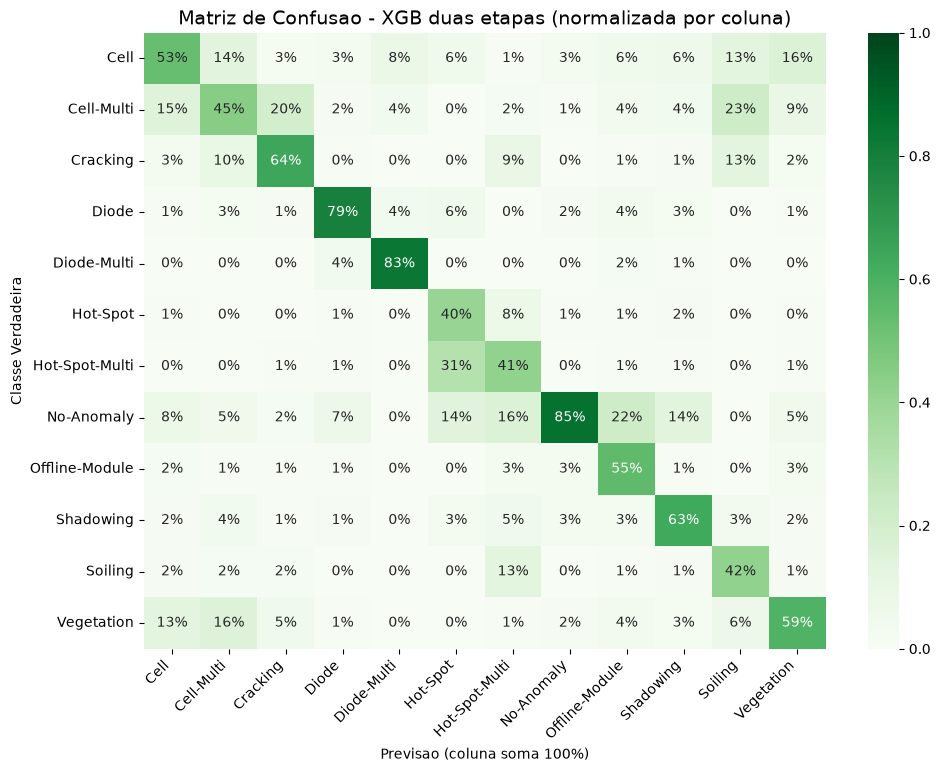

In [30]:
matriz_xgb2 = confusion_matrix(y_te, pred_xgb_final, labels=classes, normalize="pred")
plt.figure(figsize=(11, 8))
sns.heatmap(matriz_xgb2, annot=True, fmt=".0%", cmap="Greens", vmin=0, vmax=1,
            xticklabels=classes, yticklabels=classes)
plt.title("Matriz de Confusao - XGB duas etapas (normalizada por coluna)", fontsize=14)
plt.ylabel("Classe Verdadeira")
plt.xlabel("Previsao (coluna soma 100%)")
plt.xticks(rotation=45, ha="right")
plt.show()

### 5.4 XGBoost — Modelo único (12 classes) + matriz

In [31]:
le = LabelEncoder().fit(y)
xgb_unico = make_xgb()
xgb_unico.fit(X_tr, le.transform(y_tr), sample_weight=compute_sample_weight("balanced", y_tr))
pred_xgb_unico = le.inverse_transform(xgb_unico.predict(X_te))

print(f"XGB unico — acuracia: {accuracy_score(y_te, pred_xgb_unico) * 100:.1f}% | "
      f"F1 macro: {f1_score(y_te, pred_xgb_unico, average='macro') * 100:.1f}%\n")
print("--- Relatorio por classe (XGB unico) ---")
print(classification_report(y_te, pred_xgb_unico, zero_division=0))

XGB unico — acuracia: 74.2% | F1 macro: 53.9%

--- Relatorio por classe (XGB unico) ---
                precision    recall  f1-score   support

          Cell       0.55      0.49      0.52       563
    Cell-Multi       0.47      0.30      0.37       386
      Cracking       0.64      0.72      0.68       282
         Diode       0.86      0.78      0.82       450
   Diode-Multi       0.75      0.35      0.47        52
      Hot-Spot       0.52      0.23      0.31        75
Hot-Spot-Multi       0.40      0.43      0.42        74
    No-Anomaly       0.82      0.96      0.88      3000
Offline-Module       0.69      0.44      0.53       248
     Shadowing       0.70      0.50      0.58       317
       Soiling       0.41      0.21      0.28        61
    Vegetation       0.62      0.57      0.59       492

      accuracy                           0.74      6000
     macro avg       0.62      0.50      0.54      6000
  weighted avg       0.72      0.74      0.72      6000



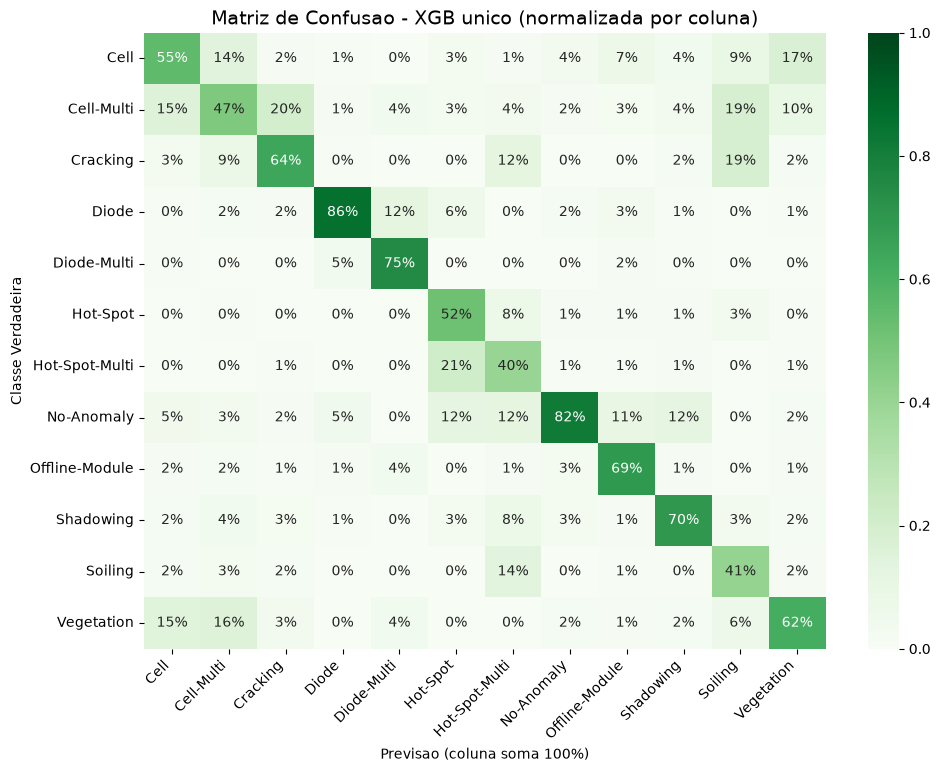

In [32]:
matriz_xgb1 = confusion_matrix(y_te, pred_xgb_unico, labels=classes, normalize="pred")
plt.figure(figsize=(11, 8))
sns.heatmap(matriz_xgb1, annot=True, fmt=".0%", cmap="Greens", vmin=0, vmax=1,
            xticklabels=classes, yticklabels=classes)
plt.title("Matriz de Confusao - XGB unico (normalizada por coluna)", fontsize=14)
plt.ylabel("Classe Verdadeira")
plt.xlabel("Previsao (coluna soma 100%)")
plt.xticks(rotation=45, ha="right")
plt.show()

## 6. Resumo XGBoost: único vs duas etapas

In [33]:
def metricas(nome, pred):
    return {"config": nome,
            "acuracia": round(accuracy_score(y_te, pred) * 100, 1),
            "f1_macro": round(f1_score(y_te, pred, average="macro") * 100, 1)}


resumo = pd.DataFrame([
    metricas("XGB unico", pred_xgb_unico),
    metricas("XGB duas etapas", pred_xgb_final),
]).set_index("config")
print(resumo.sort_values("f1_macro", ascending=False))

                 acuracia  f1_macro
config                             
XGB unico            74.2      53.9
XGB duas etapas      73.6      53.7


## 7. Análise de confusão entre classes

Quais classes o modelo (XGB único) mais troca entre si. Lido da matriz de confusão
**normalizada por linha** (recall): para cada classe verdadeira, qual % foi prevista
como cada outra. Ajuda a decidir quais classes vale agrupar.

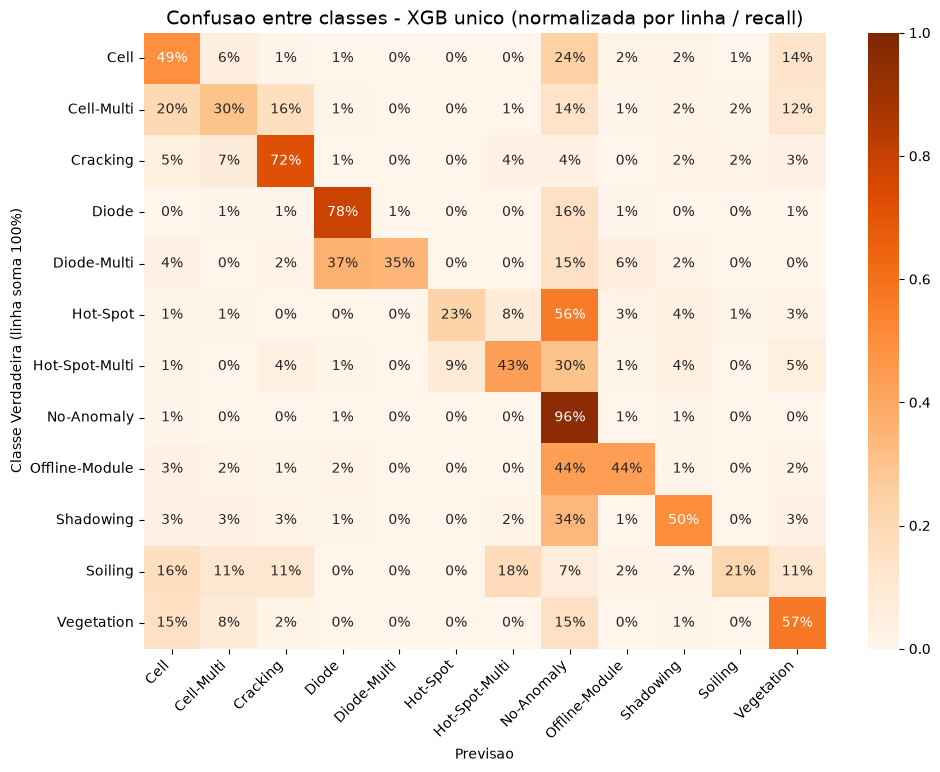

In [34]:
cm = confusion_matrix(y_te, pred_xgb_unico, labels=classes)
cm_norm = cm / cm.sum(axis=1, keepdims=True)  # por linha (recall)

plt.figure(figsize=(11, 8))
sns.heatmap(cm_norm, annot=True, fmt=".0%", cmap="Oranges", vmin=0, vmax=1,
            xticklabels=classes, yticklabels=classes)
plt.title("Confusao entre classes - XGB unico (normalizada por linha / recall)", fontsize=14)
plt.ylabel("Classe Verdadeira (linha soma 100%)")
plt.xlabel("Previsao")
plt.xticks(rotation=45, ha="right")
plt.show()

In [35]:
# Para cada classe: com quem mais se confunde (fora a diagonal)
print("Classe verdadeira -> com quem mais confunde:")
for i, real in enumerate(classes):
    fora = cm_norm[i].copy()
    fora[i] = 0
    j = int(fora.argmax())
    print(f"  {real:16s} -> {classes[j]:16s} ({fora[j]*100:4.1f}% dos {real}; acerto proprio {cm_norm[i, i]*100:.0f}%)")

Classe verdadeira -> com quem mais confunde:
  Cell             -> No-Anomaly       (24.3% dos Cell; acerto proprio 49%)
  Cell-Multi       -> Cell             (20.2% dos Cell-Multi; acerto proprio 30%)
  Cracking         -> Cell-Multi       ( 7.4% dos Cracking; acerto proprio 72%)
  Diode            -> No-Anomaly       (15.6% dos Diode; acerto proprio 78%)
  Diode-Multi      -> Diode            (36.5% dos Diode-Multi; acerto proprio 35%)
  Hot-Spot         -> No-Anomaly       (56.0% dos Hot-Spot; acerto proprio 23%)
  Hot-Spot-Multi   -> No-Anomaly       (29.7% dos Hot-Spot-Multi; acerto proprio 43%)
  No-Anomaly       -> Shadowing        ( 0.9% dos No-Anomaly; acerto proprio 96%)
  Offline-Module   -> No-Anomaly       (43.5% dos Offline-Module; acerto proprio 44%)
  Shadowing        -> No-Anomaly       (34.1% dos Shadowing; acerto proprio 50%)
  Soiling          -> Hot-Spot-Multi   (18.0% dos Soiling; acerto proprio 21%)
  Vegetation       -> Cell             (15.2% dos Vegetation; a

In [36]:
# Ranking dos pares de confusao mais fortes (real != previsto)
pares = []
for i, real in enumerate(classes):
    for j, prev in enumerate(classes):
        if i != j and cm[i, j] > 0:
            pares.append({"real": real, "previsto": prev,
                          "n": int(cm[i, j]), "pct_da_real": round(cm_norm[i, j] * 100, 1)})
conf = pd.DataFrame(pares).sort_values("pct_da_real", ascending=False)
print("\nTop 15 confusoes (% da classe verdadeira):")
print(conf.head(15).to_string(index=False))


Top 15 confusoes (% da classe verdadeira):
          real       previsto   n  pct_da_real
      Hot-Spot     No-Anomaly  42         56.0
Offline-Module     No-Anomaly 108         43.5
   Diode-Multi          Diode  19         36.5
     Shadowing     No-Anomaly 108         34.1
Hot-Spot-Multi     No-Anomaly  22         29.7
          Cell     No-Anomaly 137         24.3
    Cell-Multi           Cell  78         20.2
       Soiling Hot-Spot-Multi  11         18.0
       Soiling           Cell  10         16.4
    Cell-Multi       Cracking  63         16.3
         Diode     No-Anomaly  70         15.6
   Diode-Multi     No-Anomaly   8         15.4
    Vegetation           Cell  75         15.2
    Vegetation     No-Anomaly  75         15.2
    Cell-Multi     No-Anomaly  55         14.2


## 8. Features que atrapalham (candidatas a remover)

**Importância por permutação**: embaralha cada feature e mede quanto o F1 macro cai.
Importância ≈ 0 ou **negativa** = feature que não ajuda (ou atrapalha) → candidata a
remover. Mais confiável que a importância nativa do modelo.

In [37]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    xgb_unico, X_te, le.transform(y_te),
    n_repeats=5, random_state=42, scoring="f1_macro", n_jobs=-1)
imp = pd.DataFrame({"feature": FEAT_NAMES,
                    "imp_mean": perm.importances_mean,
                    "imp_std": perm.importances_std}).sort_values("imp_mean")

candidatas = imp[imp["imp_mean"] <= 0]
print(f"{len(candidatas)} features com importancia <= 0 (candidatas a remover):")
print(candidatas.head(20).to_string(index=False))

print("\nTop 12 features mais uteis:")
print(imp.tail(12)[::-1].to_string(index=False))

56 features com importancia <= 0 (candidatas a remover):
       feature  imp_mean  imp_std
       hog_105 -0.004237 0.001762
       row_cov -0.003806 0.003541
        hog_74 -0.003114 0.001136
        hog_96 -0.003073 0.001433
         hog_3 -0.002964 0.001586
        hog_60 -0.002525 0.001953
        hog_81 -0.002507 0.002118
       hog_103 -0.002205 0.001347
        hog_71 -0.002029 0.000981
        hog_67 -0.001971 0.001226
   gabor2_mean -0.001894 0.002073
        hog_11 -0.001761 0.002349
        hog_33 -0.001759 0.000647
         hog_1 -0.001607 0.001665
largest_aspect -0.001581 0.002715
        hog_49 -0.001558 0.001098
        hog_18 -0.001369 0.002545
        hog_40 -0.001337 0.000629
         hog_4 -0.001334 0.001522
       hog_114 -0.001318 0.000767

Top 12 features mais uteis:
   feature  imp_mean  imp_std
   max_int  0.127300 0.006481
gabor2_std  0.038957 0.002745
  skew_int  0.030462 0.002852
   grid_11  0.011357 0.000923
gabor1_std  0.010823 0.001626
    hog_56  0.009854

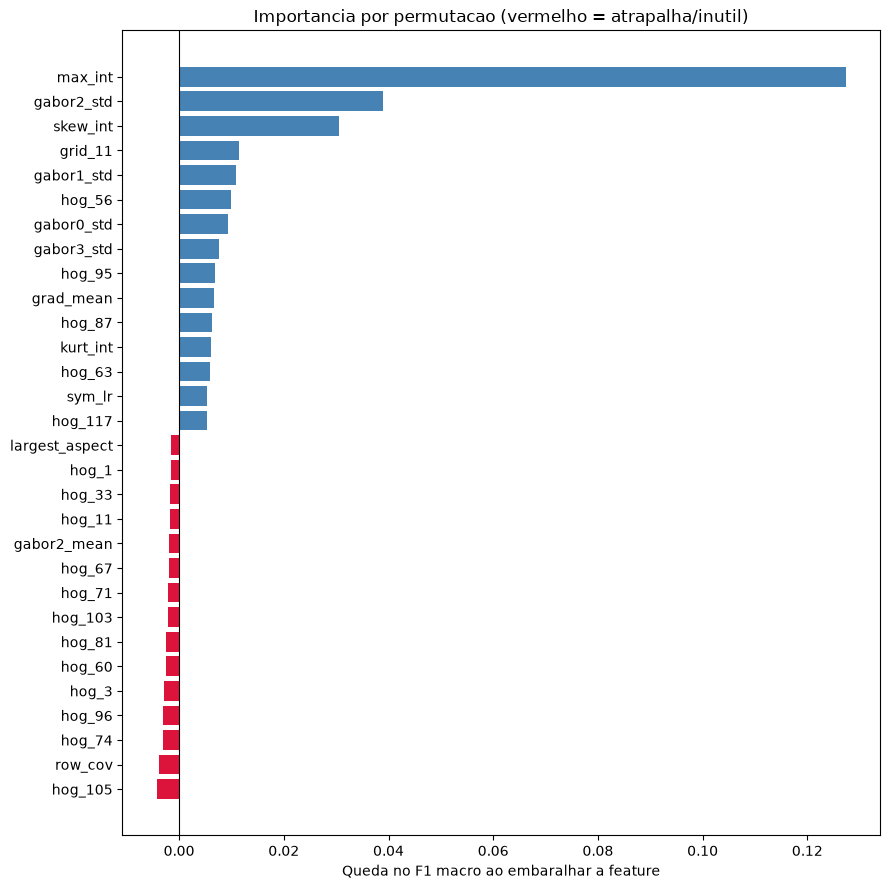

In [38]:
# Visualiza as 15 piores e 15 melhores
extremos = pd.concat([imp.head(15), imp.tail(15)])
plt.figure(figsize=(9, 9))
cores = ["crimson" if v <= 0 else "steelblue" for v in extremos["imp_mean"]]
plt.barh(extremos["feature"], extremos["imp_mean"], color=cores)
plt.axvline(0, color="black", lw=0.8)
plt.title("Importancia por permutacao (vermelho = atrapalha/inutil)")
plt.xlabel("Queda no F1 macro ao embaralhar a feature")
plt.tight_layout()
plt.show()

## 9. Remover as features candidatas e comparar

Mantemos só as features com importância > 0 (removemos as ≤ 0) e re-treinamos o
XGBoost único. Comparamos desempenho geral e por classe vs o conjunto completo.

*Obs.: a importância foi medida no mesmo conjunto de teste, então há um leve viés
otimista na seleção; serve como indicativo, não prova definitiva.*

In [39]:
manter = imp[imp["imp_mean"] > 0]["feature"].tolist()
manter_idx = [FEAT_NAMES.index(f) for f in manter]
X_tr_sel, X_te_sel = X_tr[:, manter_idx], X_te[:, manter_idx]
print(f"Features: {len(FEAT_NAMES)} -> {len(manter)} (removidas {len(FEAT_NAMES) - len(manter)})")

xgb_sel = make_xgb()
xgb_sel.fit(X_tr_sel, le.transform(y_tr), sample_weight=compute_sample_weight("balanced", y_tr))
pred_sel = le.inverse_transform(xgb_sel.predict(X_te_sel))

print(f"\nXGB completo ({len(FEAT_NAMES)} feat)  — acuracia: {accuracy_score(y_te, pred_xgb_unico) * 100:.1f}% | "
      f"F1 macro: {f1_score(y_te, pred_xgb_unico, average='macro') * 100:.1f}%")
print(f"XGB reduzido ({len(manter)} feat) — acuracia: {accuracy_score(y_te, pred_sel) * 100:.1f}% | "
      f"F1 macro: {f1_score(y_te, pred_sel, average='macro') * 100:.1f}%")

Features: 181 -> 125 (removidas 56)

XGB completo (181 feat)  — acuracia: 74.2% | F1 macro: 53.9%
XGB reduzido (125 feat) — acuracia: 74.0% | F1 macro: 53.6%


In [40]:
# Desempenho por classe: completo vs reduzido
f1_full = f1_score(y_te, pred_xgb_unico, average=None, labels=classes)
f1_sel = f1_score(y_te, pred_sel, average=None, labels=classes)
tab_sel = pd.DataFrame({"F1_completo": f1_full, "F1_reduzido": f1_sel}, index=classes).round(2)
tab_sel["delta"] = (tab_sel["F1_reduzido"] - tab_sel["F1_completo"]).round(2)
print(tab_sel.sort_values("delta"))

                F1_completo  F1_reduzido  delta
Hot-Spot               0.31         0.29  -0.02
Soiling                0.28         0.26  -0.02
Offline-Module         0.53         0.52  -0.01
Cell-Multi             0.37         0.36  -0.01
No-Anomaly             0.88         0.88   0.00
Shadowing              0.58         0.58   0.00
Diode                  0.82         0.82   0.00
Cracking               0.68         0.68   0.00
Vegetation             0.59         0.59   0.00
Cell                   0.52         0.53   0.01
Hot-Spot-Multi         0.42         0.44   0.02
Diode-Multi            0.47         0.49   0.02
